# Задача 6. Классификация: SI выше медианы


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402
from src import modeling as mdl  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path.cwd().parent / "reports" / "figures"
RES_DIR = Path.cwd().parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
features, targets, groups, clean_report = du.load_dataset()
target = targets["si_gt_median"]

print(f"Признаков: {features.shape[1]}, объектов: {features.shape[0]}")
print(f"Целевая переменная: SI > медианы выборки (3.85)")
print(f"Класс 1: {int(target.sum())} объектов ({target.mean():.1%})")
print(f"Класс 0: {int((1 - target).sum())} объектов ({1 - target.mean():.1%})")

Признаков: 178, объектов: 1001
Целевая переменная: SI > медианы выборки (3.85)
Класс 1: 500 объектов (50.0%)
Класс 0: 501 объектов (50.0%)


## 2. Разбиение на обучение и отложенный тест

In [3]:
X_train, X_test, y_train, y_test, groups_train = mdl.group_train_test_split(
    features, target, groups
)
train_groups = set(groups[np.isin(features.index, X_train.index)])
test_groups = set(groups[np.isin(features.index, X_test.index)])

print(f"train: {X_train.shape[0]} объектов, доля класса 1 = {y_train.mean():.3f}")
print(f"test:  {X_test.shape[0]} объектов, доля класса 1 = {y_test.mean():.3f}")
print(f"Пересечение групп train/test: {len(train_groups & test_groups)}")

train: 798 объектов, доля класса 1 = 0.518
test:  203 объектов, доля класса 1 = 0.429
Пересечение групп train/test: 0


## 3. Подбор гиперпараметров и сравнение моделей

In [4]:
cv_table, fitted = mdl.search_candidates(
    mdl.classification_candidates(), X_train, y_train, groups_train,
    scoring="roc_auc", stratified=True, task="si_clf",
)
display(cv_table.drop(columns=["комментарий"]).round(4))

Baseline (частый класс)  CV roc_auc =  0.5000 (±0.0000)
Logistic Regression      CV roc_auc =  0.6680 (±0.0526)
kNN                      CV roc_auc =  0.7058 (±0.0285)


SVC (RBF)                CV roc_auc =  0.7097 (±0.0486)


Random Forest            CV roc_auc =  0.7249 (±0.0387)


Extra Trees              CV roc_auc =  0.7293 (±0.0382)


LightGBM                 CV roc_auc =  0.7080 (±0.0345)


XGBoost                  CV roc_auc =  0.7145 (±0.0468)


,модель,CV roc_auc,std,лучшие гиперпараметры,число обучений
0,Extra Trees,0.7293,0.0382,"{'class_weight': 'balanced', 'max_depth': 8, '...",150
1,Random Forest,0.7249,0.0387,"{'class_weight': None, 'max_depth': 6, 'max_fe...",150
2,XGBoost,0.7145,0.0468,"{'colsample_bytree': 0.80654, 'learning_rate':...",150
3,SVC (RBF),0.7097,0.0486,"{'C': 0.83864, 'class_weight': 'balanced', 'ga...",150
4,LightGBM,0.7080,0.0345,"{'class_weight': None, 'colsample_bytree': 0.7...",150
5,kNN,0.7058,0.0285,"{'n_neighbors': 16, 'p': 1, 'weights': 'distan...",150
6,Logistic Regression,0.6680,0.0526,"{'C': 0.01967, 'class_weight': 'balanced', 'pe...",150
7,Baseline (частый класс),0.5000,0.0000,{},5


In [5]:
display(cv_table[["модель", "комментарий", "лучшие гиперпараметры"]]
        .set_index("модель"))

,комментарий,лучшие гиперпараметры
модель,,
Extra Trees,усиленная рандомизация разбиений,"{'class_weight': 'balanced', 'max_depth': 8, '..."
Random Forest,бэггинг деревьев,"{'class_weight': None, 'max_depth': 6, 'max_fe..."
XGBoost,альтернативная реализация бустинга,"{'colsample_bytree': 0.80654, 'learning_rate':..."
SVC (RBF),нелинейная модель на ядре,"{'C': 0.83864, 'class_weight': 'balanced', 'ga..."
LightGBM,"градиентный бустинг, основной кандидат","{'class_weight': None, 'colsample_bytree': 0.7..."
kNN,метрическая модель,"{'n_neighbors': 16, 'p': 1, 'weights': 'distan..."
Logistic Regression,линейный baseline с регуляризацией,"{'C': 0.01967, 'class_weight': 'balanced', 'pe..."
Baseline (частый класс),нижняя граница качества: ROC-AUC = 0.5 по пост...,{}


## 4. Оценка на отложенном тесте

In [6]:
test_table = mdl.evaluate_on_test(fitted, X_test, y_test, task="classification")
display(test_table.round(3))
test_table.to_csv(RES_DIR / "si_clf_test_metrics.csv", index=False)

,модель,ROC-AUC,PR-AUC,Accuracy,Balanced acc.,F1
0,Extra Trees,0.726,0.666,0.665,0.659,0.614
1,LightGBM,0.723,0.652,0.690,0.682,0.636
2,Random Forest,0.722,0.663,0.685,0.672,0.614
3,XGBoost,0.718,0.649,0.680,0.671,0.620
4,kNN,0.718,0.648,0.650,0.662,0.647
5,SVC (RBF),0.709,0.627,0.670,0.662,0.613
6,Logistic Regression,0.669,0.587,0.670,0.667,0.626
7,Baseline (частый класс),0.500,0.429,0.429,0.500,0.600


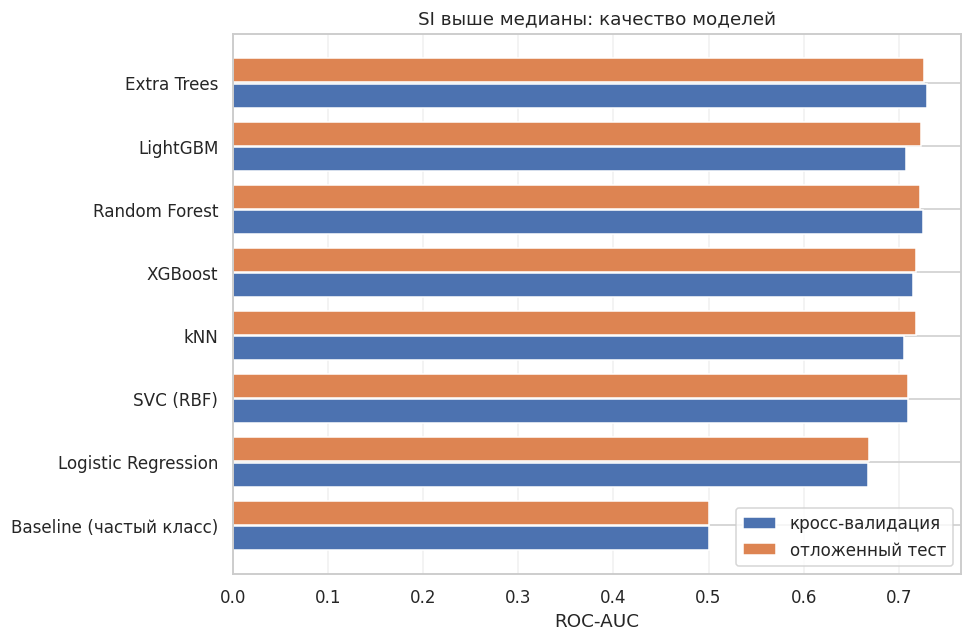

In [7]:
mdl.plot_cv_vs_test(
    cv_table, test_table, "CV roc_auc", "ROC-AUC",
    "SI выше медианы: качество моделей",
    save_path=FIG_DIR / "si_clf_models_comparison.png",
)

## 5. ROC и PR-кривые

- ROC-кривая показывает поведение модели при всех порогах
- PR-кривая информативнее при дисбалансе классов, поскольку не «вознаграждает» модель за правильное определение многочисленного отрицательного класса

Лучшая модель на тесте: Extra Trees


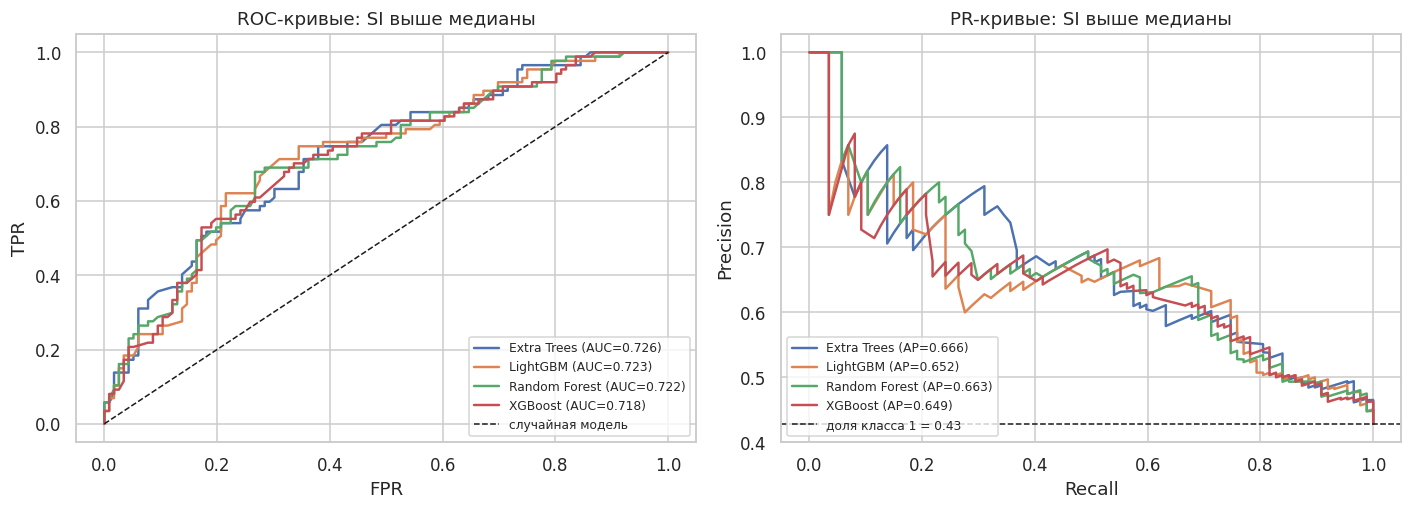

In [8]:
best_name = test_table.iloc[0]["модель"]
best_model = fitted[best_name]
print(f"Лучшая модель на тесте: {best_name}")

top_names = [n for n in test_table["модель"].head(4)]
curves = {n: fitted[n].predict_proba(X_test)[:, 1] for n in top_names}
mdl.plot_classification_diagnostics(
    y_test.to_numpy(), curves, "SI выше медианы",
    save_path=FIG_DIR / "si_clf_roc_pr.png",
)

## 6. Матрица ошибок и выбор порога

Оптимальный по F1 порог (подобран на train): 0.42


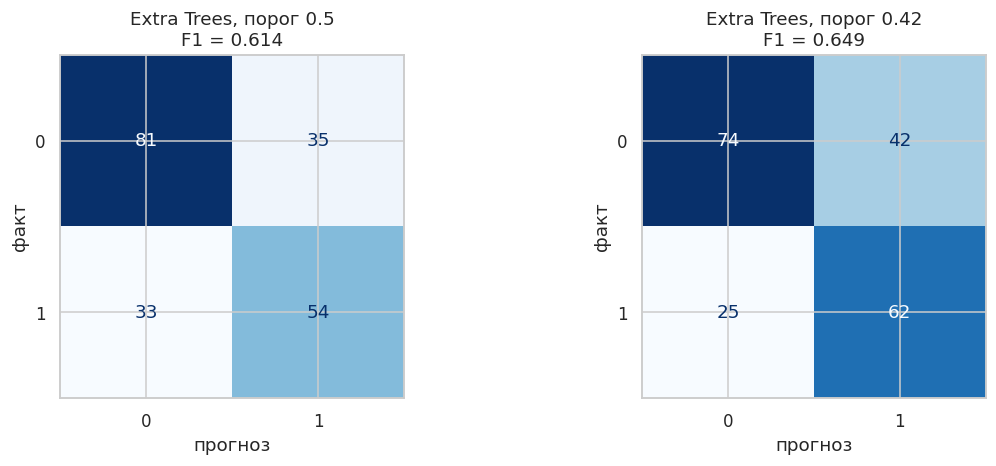

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

proba_train = best_model.predict_proba(X_train)[:, 1]
grid = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(y_train, (proba_train >= t).astype(int)) for t in grid]
best_threshold = float(grid[int(np.argmax(f1_scores))])
print(f"Оптимальный по F1 порог (подобран на train): {best_threshold:.2f}")

proba_test = best_model.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, threshold, label in [
    (axes[0], 0.5, "порог 0.5"),
    (axes[1], best_threshold, f"порог {best_threshold:.2f}"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, (proba_test >= threshold).astype(int), ax=ax,
        colorbar=False, cmap="Blues",
    )
    ax.set_title(f"{best_name}, {label}\n"
                 f"F1 = {f1_score(y_test, (proba_test >= threshold).astype(int)):.3f}")
    ax.set_xlabel("прогноз")
    ax.set_ylabel("факт")
plt.tight_layout()
plt.savefig(FIG_DIR / "si_clf_confusion.png", dpi=140, bbox_inches="tight")
plt.show()

## 7. Какие дескрипторы определяют прогноз

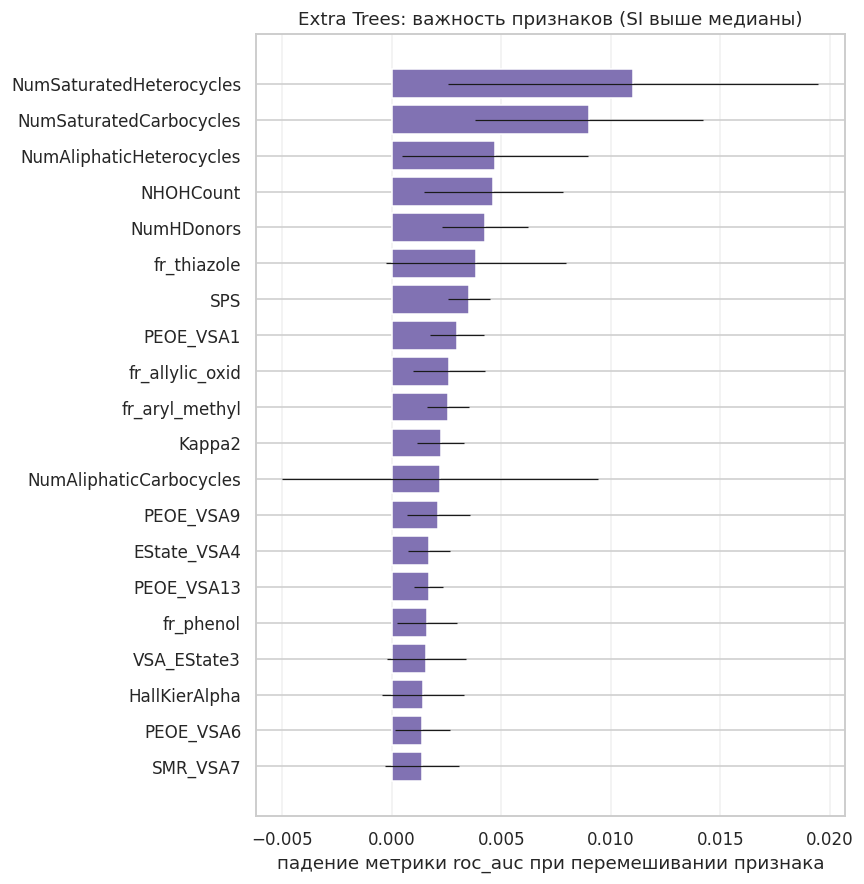

,признак,падение качества,std
0,NumSaturatedHeterocycles,0.0110,0.0084
1,NumSaturatedCarbocycles,0.0090,0.0052
2,NumAliphaticHeterocycles,0.0047,0.0042
3,NHOHCount,0.0046,0.0032
4,NumHDonors,0.0043,0.0020
5,fr_thiazole,0.0038,0.0041
6,SPS,0.0035,0.0009
7,PEOE_VSA1,0.0030,0.0012
8,fr_allylic_oxid,0.0026,0.0016
9,fr_aryl_methyl,0.0026,0.0010


In [10]:
importance = mdl.plot_permutation_importance(
    best_model, X_test, y_test, scoring="roc_auc",
    title=f"{best_name}: важность признаков (SI выше медианы)",
    save_path=FIG_DIR / "si_clf_importance.png",
)
display(importance.head(15).round(4))
importance.to_csv(RES_DIR / "si_clf_importance.csv", index=False)

## 8. Устойчивость результата

In [11]:
from sklearn.metrics import roc_auc_score

stability = mdl.stability_check(
    best_model, features, target, groups,
    scoring=lambda y_true, model, X: roc_auc_score(
        y_true, model.predict_proba(X)[:, 1]),
)
display(stability.round(4))

Среднее = 0.7090, std = 0.0369, размах = 0.0946


,seed,метрика
0,0,0.6871
1,1,0.7521
2,2,0.6575
3,3,0.7251
4,4,0.7234


## 9. Выводы по задаче «SI > медианы»

### Что показали модели

| Наблюдение | Интерпретация |
|---|---|
| CV ROC-AUC ≈ 0.73, на тесте ≈ 0.73 | Заметно скромнее, чем для CC50 (0.83), но существенно выше случайного угадывания и устойчиво воспроизводится |
| Совпадение CV и теста практически точное | Оценка качества надёжна — редкая ситуация, обычно результаты расходятся сильнее |
| Логистическая регрессия отстаёт сильнее, чем в других задачах (0.67 против 0.73) | Селективность — наиболее «нелинейный» из таргетов, что согласуется с результатами регрессии |
| Классификация SI (ROC-AUC 0.73) практически полезнее регрессии SI (R² 0.29) | При одном и том же уровне сигнала бинарная постановка даёт результат, пригодный для принятия решений |

### Сопоставление с задачей 3

Регрессия и классификация используют один сигнал, но по-разному. Что заметно , регрессия признаёт, что точный SI непредсказуем, классификация показывает, что направление (выше/ниже медианы) ловится хорошо.Берём классификацию, регрессию оставляем как оценку масштаба.